Step 1- Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.21.0
All libraries loaded successfully


Step2- Configuration

In [2]:
# update these to match your CSV file

CSV_PATH = 'Chun_Modelling.csv'         #path to your file
TARGET_COL = 'failure'             # name of your binary target column (0 or 1)

# Leave as None to use ALL columns except target
# Or list specific columns: ['pressure', 'temperature', 'vibration']
FEATURE_COLS = None

# Training settings
TEST_SIZE = 0.2

# 20% of data held out for testing
EPOCHS   = 20            # how many times the model sees the full dataset
BATCH_SIZE = 32            # samples per weight update
LEARNING_RATE = 0.001      # step size for gradient descent

print("config set successfully")


config set successfully


Step3 - Load & Explore the Data

In [4]:
# Load the csv file into a pandas DataFrame
df = pd.read_csv('Churn_Modelling.csv')

print ("Shape of dataset:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Churn_Modelling.csv'

In [ ]:
print ("Missing values in each column:")
print (df.isnull().sum())

print ("\nTarget distribution:")
print (df['Exited'].value_counts())

Missing values in each column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


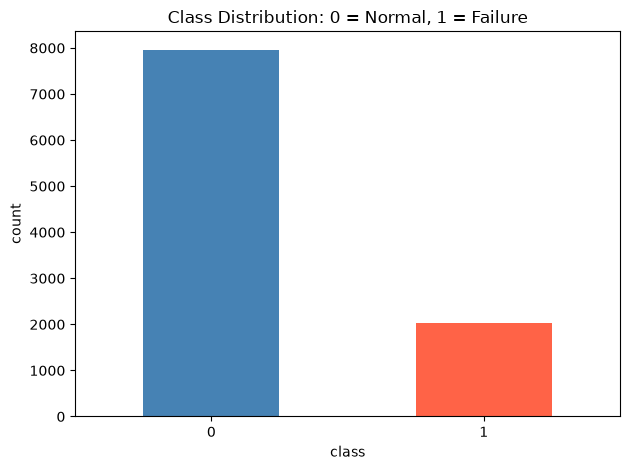

In [ ]:
#Visualize class balance as a bar chart
df['Exited'].value_counts().plot(kind='bar', color = ['steelblue', 'tomato'])
plt.title('Class Distribution: 0 = Normal, 1 = Failure')
plt.xlabel("class")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)

In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [ ]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1
5,6,15574012,Chu,645,1,44,8,113755.78,2,1,0,149756.71,1,0,1
6,7,15592531,Bartlett,822,1,50,7,0.00,2,1,1,10062.80,0,0,0
7,8,15656148,Obinna,376,0,29,4,115046.74,4,1,0,119346.88,1,1,0
8,9,15792365,He,501,1,44,4,142051.07,2,0,1,74940.50,0,0,0
9,10,15592389,H?,684,1,27,2,134603.88,1,1,1,71725.73,0,0,0


In [ ]:
if FEATURE_COLS is None:
    #Use all columns except target column
    x = df.drop(columns=["Exited", "RowNumber", "CustomerId", "Surname"])
else:
    #Use only the columns we specified
    x = df[FEATURE_COLS]
#Target variable - what we want to predict
y = df["Exited"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(x.columns))

Features shape: (10000, 11)
Target shape: (10000,)

Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=42, stratify=y)
print (f"Training samples: {len(x_train)}")
print (f"Testing samples: {len(x_test)}")

Training samples: 8000
Testing samples: 2000


In [ ]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform (x_train)
x_test = scaler.transform (x_test)

print("Normalization done successfully")
print("Train min/max after scaling:", x_train.min().round(2), "/", x_train.max().round(2))

Normalization done successfully
Train min/max after scaling: 0.0 / 1.0


In [ ]:
nn_features = x_train.shape[1]

model = Sequential([Dense(64, activation='relu', input_shape=(nn_features,)), Dropout(0.2), Dense(32, activation='relu'), Dropout(0.2), Dense(1, activation='sigmoid')])
model.summary()

c:\Users\USER\Control\day1\Exclusive\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy', metrics=['accuracy'])
print("Model compiled successfully")

Model compiled successfully


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_split=0.15, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=1)
print("\nTraining completed successfully")

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8462 - loss: 0.3597 - val_accuracy: 0.8667 - val_loss: 0.3251
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8543 - loss: 0.3550 - val_accuracy: 0.8650 - val_loss: 0.3258
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8518 - loss: 0.3552 - val_accuracy: 0.8708 - val_loss: 0.3261
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8524 - loss: 0.3575 - val_accuracy: 0.8683 - val_loss: 0.3237
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8574 - loss: 0.3504 - val_accuracy: 0.8683 - val_loss: 0.3233
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8572 - loss: 0.3535 - val_accuracy: 0.8683 - val_loss: 0.3230
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8566 - loss: 0.3546 - val_accuracy: 0.8708 - val_loss: 0.3235
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8554 - loss: 0.3536 - val_accuracy: 0.